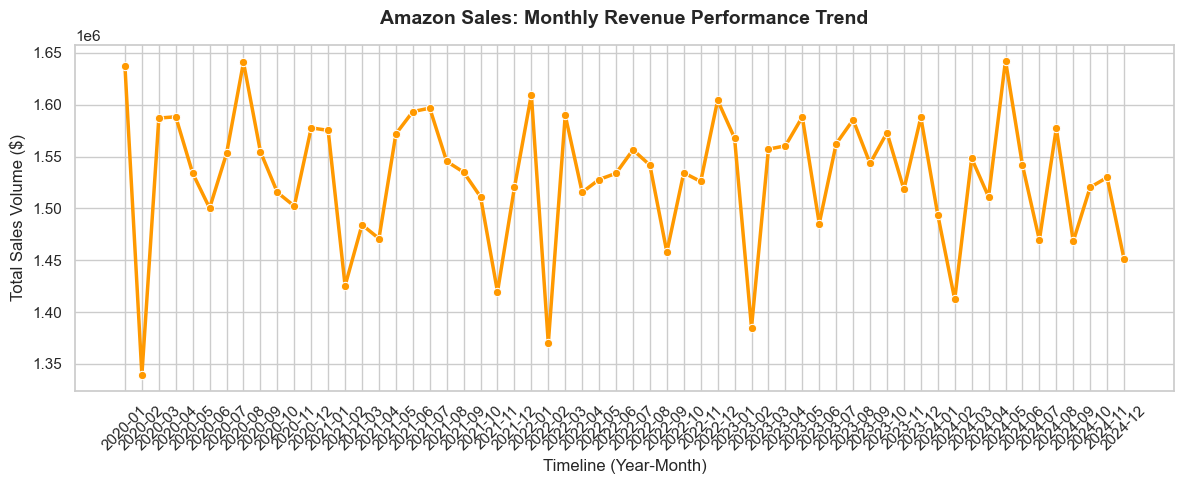

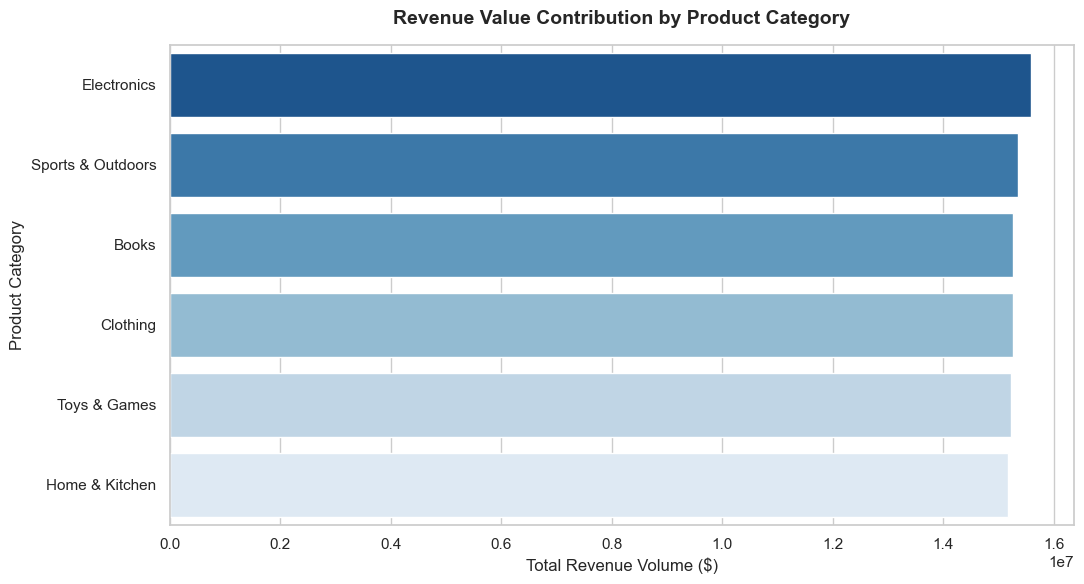

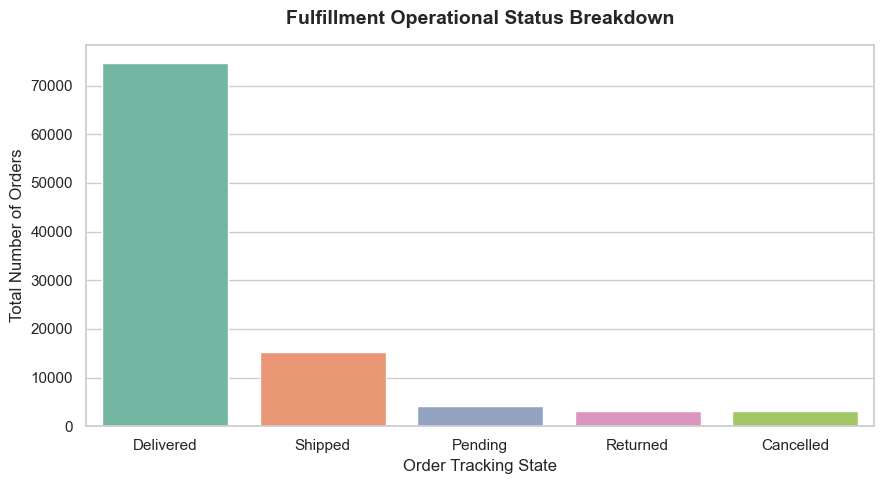

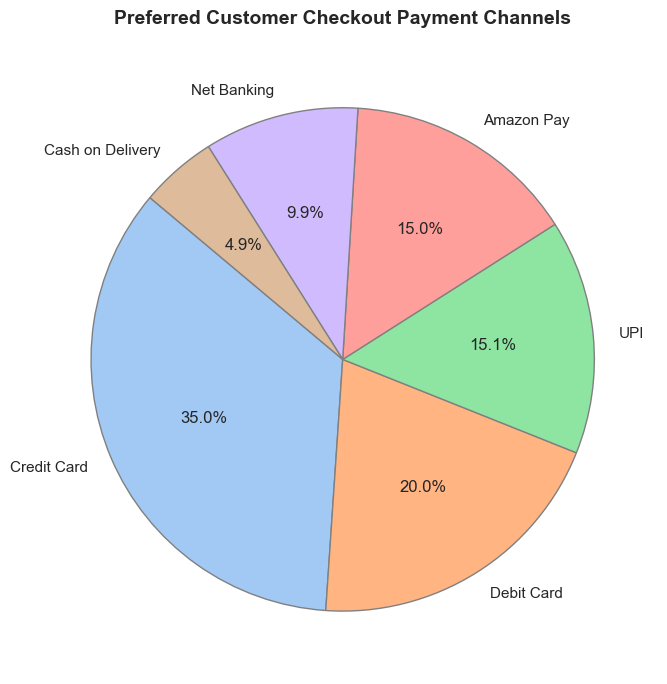

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Set visual configuration properties cleanly
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6)})

# --- 1. DATA LOADING & CLEANING ---
# Load dataset from your data directory
df = pd.read_csv('../data/amazon.csv')

# Convert OrderDate to standard datetime object
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Extract Year-Month for chronological trend analysis
df['YearMonth'] = df['OrderDate'].dt.to_period('M')

# Strip hidden whitespace characters from string data columns
for col in ['Category', 'PaymentMethod', 'OrderStatus']:
    df[col] = df[col].astype(str).str.strip()

# Drop rows missing critical financial or tracking keys
df = df.dropna(subset=['OrderID', 'TotalAmount'])


# --- 2. VISUALIZATION 1: MONTHLY REVENUE TREND ---
monthly_revenue = df.groupby('YearMonth')['TotalAmount'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x='YearMonth', y='TotalAmount', marker='o', color='#FF9900', linewidth=2.5)
plt.title('Amazon Sales: Monthly Revenue Performance Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Total Sales Volume ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- 3. VISUALIZATION 2: REVENUE BY CATEGORY ---
category_perf = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(11, 6))
sns.barplot(data=category_perf, x='TotalAmount', y='Category', palette='Blues_r')
plt.title('Revenue Value Contribution by Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue Volume ($)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()


# --- 4. VISUALIZATION 3: ORDER STATUS BREAKDOWN ---
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='OrderStatus', palette='Set2', order=df['OrderStatus'].value_counts().index)
plt.title('Fulfillment Operational Status Breakdown', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Order Tracking State', fontsize=12)
plt.ylabel('Total Number of Orders', fontsize=12)
plt.tight_layout()
plt.show()


# --- 5. VISUALIZATION 4: PAYMENT CHANNEL PREFERENCES ---
payment_shares = df['PaymentMethod'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(payment_shares, labels=payment_shares.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=140, wedgeprops={'edgecolor': 'gray'})
plt.title('Preferred Customer Checkout Payment Channels', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

